In [83]:
#import 
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from scipy import signal
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
sys.path.append(os.getcwd())
from Header import *

print("成功導入函數")

成功導入函數


In [72]:
#設定路徑
current_dir = os.getcwd()
dataset_path = os.path.join(current_dir, "dataset", "Wearable_Dataset")
stress_level_v1_path = os.path.join(current_dir, "stress_level_v1.csv")
stress_level_v2_path = os.path.join(current_dir, "stress_level_v2.csv")
print(f"資料集路徑: {dataset_path}")
print(f"路徑存在: {os.path.exists(dataset_path)}")

資料集路徑: d:\code\CSE\CSE 881\STT881-project\dataset\Wearable_Dataset
路徑存在: True


In [87]:
#讀資料
stress_level_v1_path = os.path.join(current_dir, "dataset", "Stress_Level_v1.csv")
stress_level_v2_path = os.path.join(current_dir, "dataset", "Stress_Level_v2.csv"),
states=os.listdir(dataset_path) #['AEROBIC', 'ANAEROBIC', 'STRESS']

signal_data={}
time_data={}
fs_dict={}
participants={}

for state in states:
    folder_path = f'{dataset_path}/{state}' 
    participants[state]=os.listdir(folder_path)
    signal_data[state], time_data[state], fs_dict[state] =read_signals(folder_path)
print("=" * 50)
print("overview")
print("=" * 50)

for state in states:
    print(f"\n{state}:")
    print(f"  participants number: {len(participants[state])}")
    print(f"  participants: {participants[state]}")
    

overview

AEROBIC:
  participants number: 31
  participants: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11_a', 'S11_b', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18']

ANAEROBIC:
  participants number: 32
  participants: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16_a', 'S16_b', 'S17', 'S18']

STRESS:
  participants number: 37
  participants: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08', 'f09', 'f10', 'f11', 'f12', 'f13', 'f14_a', 'f14_b', 'f15', 'f16', 'f17', 'f18', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18']


In [ ]:
# overview
print("="*80)
print("data overview")
print("="*80)

# 參與者數量
print("\n1. participants:")
for state in participants:
    print(f"   {state}: {len(participants[state])} participants")

# 各狀態、各參與者的訊號長度統計
print("\n2. signal duration statistics (seconds):")
for state in signal_data:
    print(f"\n   {state}:")
    for subject in list(signal_data[state].keys())[:3]: 
        print(f"      {subject}:")
        for sig_name in ['EDA', 'HR', 'TEMP']:
            if sig_name in signal_data[state][subject]:
                duration = time_data[state][subject][sig_name][-1]
                print(f"         {sig_name}: {duration:.1f} sec")

data overview

1. participants:
   AEROBIC: 31 participants
   ANAEROBIC: 32 participants
   STRESS: 37 participants

2. signal duration statistics (seconds):

   AEROBIC:
      f01:
         EDA: 2698.5 sec
         HR: 2689.0 sec
         TEMP: 2698.0 sec
      f02:
         EDA: 1755.0 sec
         HR: 1747.0 sec
         TEMP: 1754.0 sec
      f03:
         EDA: 2694.0 sec
         HR: 2687.0 sec
         TEMP: 2698.0 sec

   ANAEROBIC:
      f01:
         EDA: 2617.5 sec
         HR: 2610.0 sec
         TEMP: 2620.0 sec
      f02:
         EDA: 2392.5 sec
         HR: 2382.0 sec
         TEMP: 2388.0 sec
      f03:
         EDA: 2941.5 sec
         HR: 2930.0 sec
         TEMP: 2942.0 sec

   STRESS:
      f01:
         EDA: 3252.0 sec
         HR: 3243.0 sec
         TEMP: 3248.0 sec
      f02:
         EDA: 2976.0 sec
         HR: 2966.0 sec
         TEMP: 2978.0 sec
      f03:
         EDA: 3597.0 sec
         HR: 3586.0 sec
         TEMP: 3594.0 sec


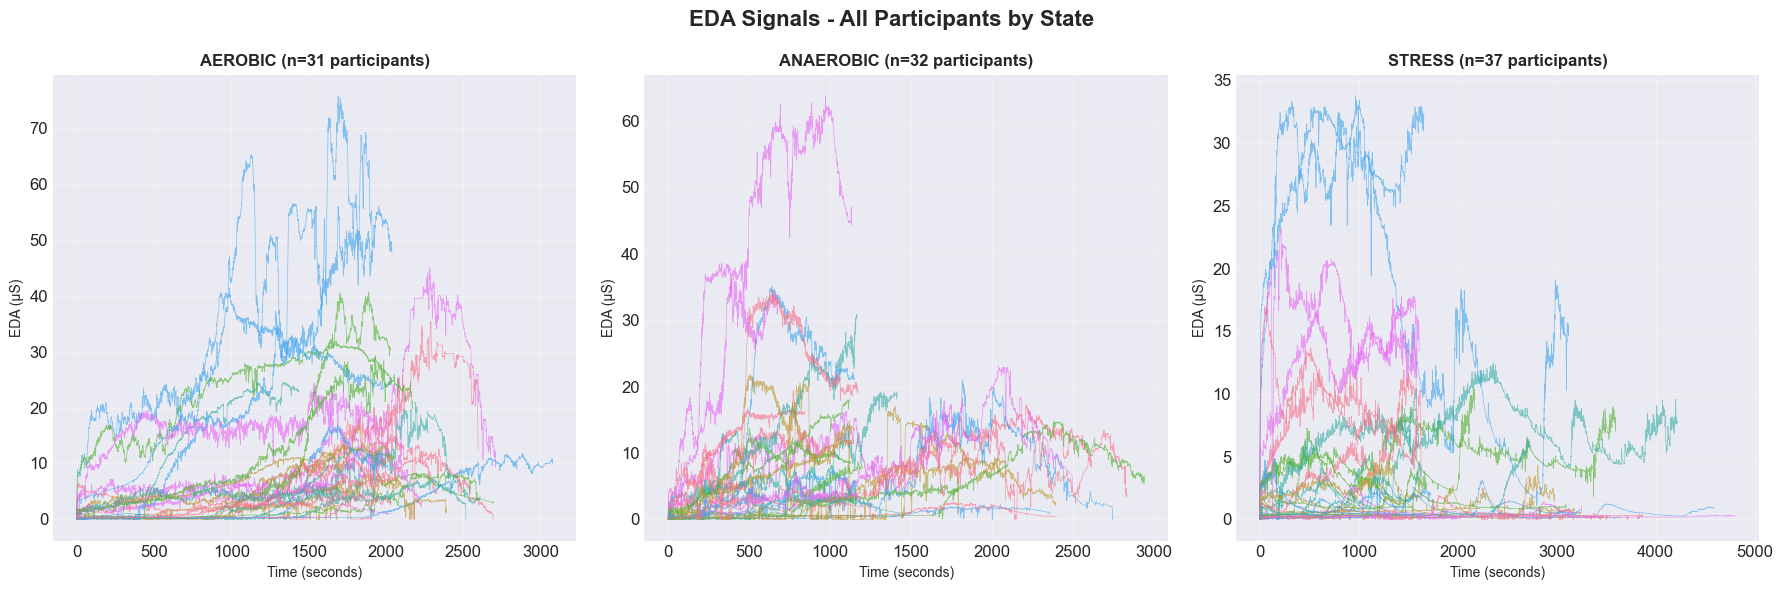

In [ ]:
# 設定繪圖風格
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)

# ============================================
# 1. 顯示所有參與者的 EDA 時間序列
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('EDA Signals - All Participants by State', fontsize=16, fontweight='bold')

for idx, state in enumerate(['AEROBIC', 'ANAEROBIC', 'STRESS']):
    ax = axes[idx]
    
    for subject in participants[state]:
        if 'EDA' in signal_data[state][subject]:
            eda = signal_data[state][subject]['EDA']
            eda_time = time_data[state][subject]['EDA']
            
            plot_len = len(eda)
            
            ax.plot(eda_time[:plot_len], eda[:plot_len], 
                   linewidth=0.5, alpha=0.6, label=subject if len(participants[state]) <= 5 else '')
    
    ax.set_title(f'{state} (n={len(participants[state])} participants)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (seconds)', fontsize=10)
    ax.set_ylabel('EDA (µS)', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    if len(participants[state]) <= 5:
        ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

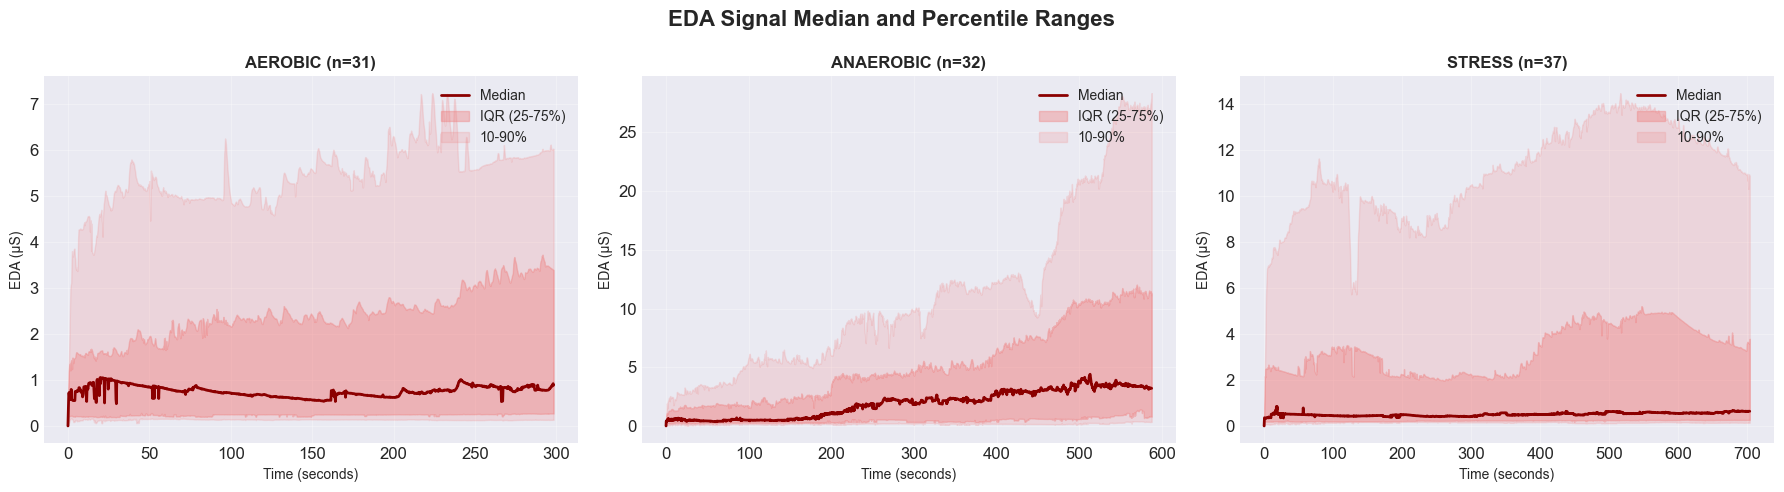

In [93]:
# ============================================
# 3. 顯示中位數和百分位數範圍
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA Signal Median and Percentile Ranges', fontsize=16, fontweight='bold')

for idx, state in enumerate(['AEROBIC', 'ANAEROBIC', 'STRESS']):
    ax = axes[idx]
    
    all_signals = []
    min_length = float('inf')
    
    for subject in participants[state]:
        if 'EDA' in signal_data[state][subject]:
            eda = signal_data[state][subject]['EDA']
            plot_len = min(5000, len(eda))
            eda_1d = eda[:plot_len].flatten()
            all_signals.append(eda_1d)
            min_length = min(min_length, plot_len)
    
    all_signals = [sig[:min_length] for sig in all_signals]
    all_signals = np.array(all_signals)
    
    median_signal = np.median(all_signals, axis=0)      
    q25_signal = np.percentile(all_signals, 25, axis=0)  
    q75_signal = np.percentile(all_signals, 75, axis=0) 
    q10_signal = np.percentile(all_signals, 10, axis=0) 
    q90_signal = np.percentile(all_signals, 90, axis=0)  
    
    fs = 4  
    time_axis = np.arange(len(median_signal)) / fs
    
    ax.plot(time_axis, median_signal, linewidth=2, color='darkred', label='Median')
    ax.fill_between(time_axis, q25_signal, q75_signal, 
                    alpha=0.4, color='lightcoral', label='IQR (25-75%)')
    ax.fill_between(time_axis, q10_signal, q90_signal, 
                    alpha=0.2, color='lightcoral', label='10-90%')
    
    ax.set_title(f'{state} (n={len(participants[state])})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (seconds)', fontsize=10)
    ax.set_ylabel('EDA (µS)', fontsize=10)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

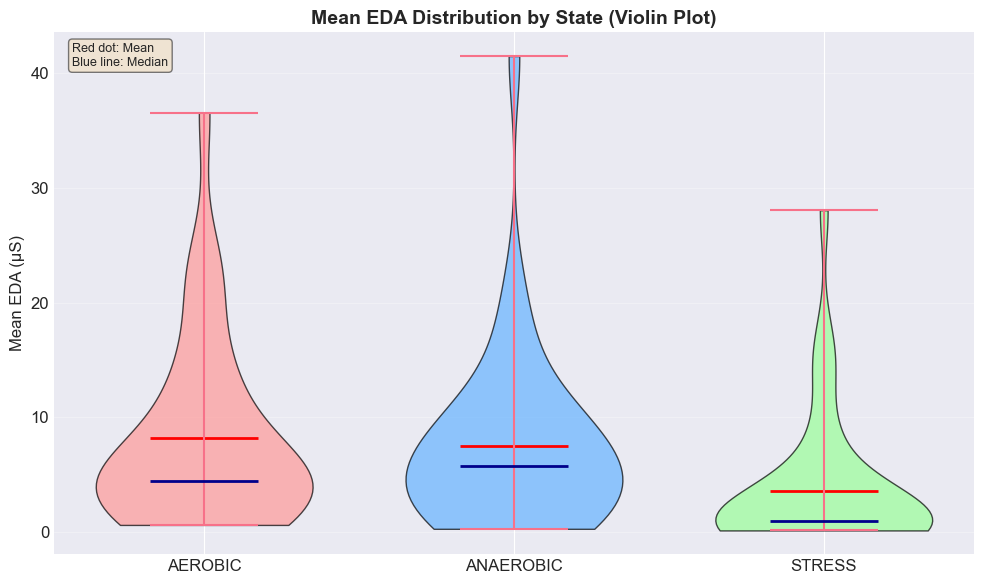

In [ ]:
# ============================================
# 小提琴圖
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

box_data = [participant_means['AEROBIC'], 
            participant_means['ANAEROBIC'], 
            participant_means['STRESS']]

parts = ax.violinplot(box_data, positions=[1, 2, 3], 
                      showmeans=True, showmedians=True,
                      widths=0.7)

colors = ['#ff9999', '#66b3ff', '#99ff99']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')

parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('darkblue')
parts['cmedians'].set_linewidth(2)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['AEROBIC', 'ANAEROBIC', 'STRESS'])
ax.set_title('Mean EDA Distribution by State (Violin Plot)', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean EDA (µS)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

ax.text(0.02, 0.98, 'Red dot: Mean\nBlue line: Median', 
        transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [94]:
# ============================================
# data preprocessing
# ============================================
signal_data_processed = {}
time_data_processed = {}
fs_dict_processed = {}

print("="*50)

for state in ['AEROBIC', 'ANAEROBIC', 'STRESS']:
    signal_data_processed[state] = {}
    time_data_processed[state] = {}
    fs_dict_processed[state] = {}
    
    for subject in participants[state]:
        signal_data_processed[state][subject] = {}
        time_data_processed[state][subject] = {}
        fs_dict_processed[state][subject] = {}
        
        for sig_name in signal_data[state][subject]:
            signal_raw = signal_data[state][subject][sig_name]
            time_array = time_data[state][subject][sig_name]
            fs = fs_dict[state][subject][sig_name]
            
            if hasattr(signal_raw, 'ndim') and signal_raw.ndim > 1:
                signal_raw = signal_raw.flatten()
            
            if len(signal_raw) == 0 or sig_name == 'tags':
                signal_data_processed[state][subject][sig_name] = signal_raw
                time_data_processed[state][subject][sig_name] = time_array
                fs_dict_processed[state][subject][sig_name] = fs
                continue
            
            try:
                if sig_name == 'EDA':
                    mean_val = np.mean(signal_raw)
                    std_val = np.std(signal_raw)
                    signal_clean = np.clip(signal_raw, mean_val - 3*std_val, mean_val + 3*std_val)
                    
                    if fs > 0 and len(signal_clean) > 10:
                        try:
                            signal_filtered = butter_lowpass_filter(signal_clean, cutoff=1.0, fs=fs)
                        except Exception as e:
                            print(f"  fail {state}-{subject}-{sig_name}: {e}")
                            signal_filtered = signal_clean
                    else:
                        signal_filtered = signal_clean
                    
                    if np.std(signal_filtered) > 0:
                        signal_processed = (signal_filtered - np.mean(signal_filtered)) / np.std(signal_filtered)
                    else:
                        signal_processed = signal_filtered
                    
                elif sig_name == 'HR':
                    mean_val = np.mean(signal_raw)
                    std_val = np.std(signal_raw)
                    signal_clean = np.clip(signal_raw, mean_val - 3*std_val, mean_val + 3*std_val)
                    
                    if np.std(signal_clean) > 0:
                        signal_processed = (signal_clean - np.mean(signal_clean)) / np.std(signal_clean)
                    else:
                        signal_processed = signal_clean
                    
                elif sig_name == 'TEMP':
                    if np.std(signal_raw) > 0:
                        signal_processed = (signal_raw - np.mean(signal_raw)) / np.std(signal_raw)
                    else:
                        signal_processed = signal_raw
                    
                elif sig_name == 'ACC':
                    if signal_raw.ndim == 2 and signal_raw.shape[1] == 3:
                        signal_processed = np.zeros_like(signal_raw)
                        for axis in range(3):
                            axis_data = signal_raw[:, axis]
                            if np.std(axis_data) > 0:
                                signal_processed[:, axis] = (axis_data - np.mean(axis_data)) / np.std(axis_data)
                            else:
                                signal_processed[:, axis] = axis_data
                    else:
                        if np.std(signal_raw) > 0:
                            signal_processed = (signal_raw - np.mean(signal_raw)) / np.std(signal_raw)
                        else:
                            signal_processed = signal_raw
                    
                else:
                    if np.std(signal_raw) > 0:
                        signal_processed = (signal_raw - np.mean(signal_raw)) / np.std(signal_raw)
                    else:
                        signal_processed = signal_raw
                
                signal_data_processed[state][subject][sig_name] = signal_processed
                time_data_processed[state][subject][sig_name] = time_array
                fs_dict_processed[state][subject][sig_name] = fs
                
            except Exception as e:
                print(f"  處理失敗 {state}-{subject}-{sig_name}: {e}")
                signal_data_processed[state][subject][sig_name] = signal_raw
                time_data_processed[state][subject][sig_name] = time_array
                fs_dict_processed[state][subject][sig_name] = fs

print("\ncomplete!")


complete!
